# Piecewise linear function

## Upper Envelope

$$
U(x) = \max \{ f_1(x), f_2(x), f_3(x) \}
$$

In [1]:
%pip install numpy
%pip install matplotlib
%pip install itertools

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append('ipynb/location/packages')

In [3]:
from packages.Point import FunctionPlotter
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

In [4]:
from packages.GraphView import Graph

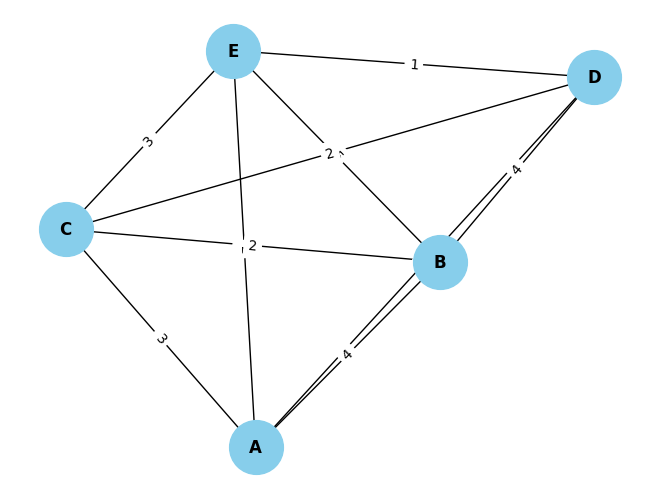

In [5]:
Global = [
    [0, 4, 3, 1, 2],
    [4, 0, 2, 4, 5],
    [3, 2, 0, 2, 3],
    [1, 4, 2, 0, 1],
    [2, 5, 3, 1, 0]
]
ShowGraph = Graph(Global)
ShowGraph.show()

DC

In [6]:
def DA(x):
    return 1 + 2*x

def DB(x):
    return 4 + 2*x

def DE(x):
    return 1 + 2*x

def CA(x):
    return 3 + (1-x)*2

def CB(x):
    return 2 + (1-x)*2

def CE(x):
    return 3 + (1-x)*2

def DC(x):
    return 2 - x

def CD(x):
    return x

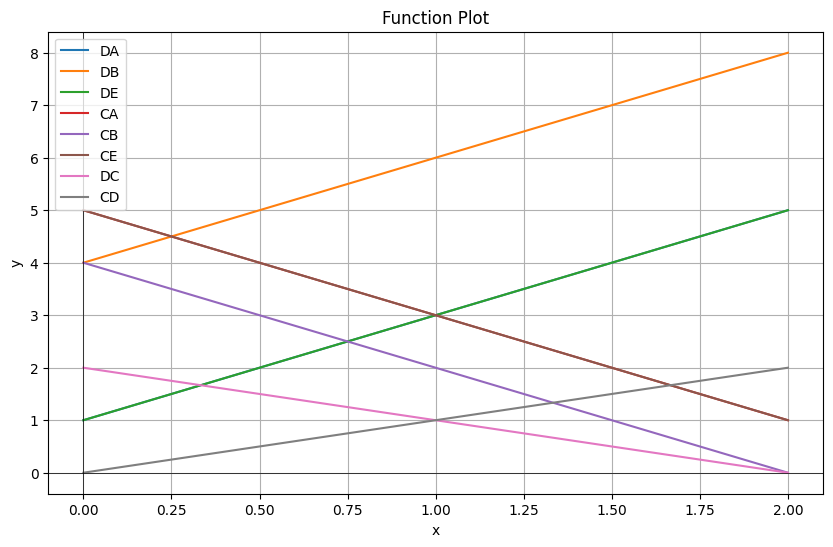

In [7]:
plotter = FunctionPlotter(0, 2, 100)
plotter.add_function(DA, "DA")
plotter.add_function(DB, "DB")
plotter.add_function(DE, "DE")
plotter.add_function(CA, "CA")
plotter.add_function(CB, "CB")
plotter.add_function(CE, "CE")
plotter.add_function(DC, "DC")
plotter.add_function(CD, "CD")
plotter.plot()

$$
U_{\text{(Function Plot)}}(x) = \max \{x, -x+4, x+3 \}
$$

In [8]:
lines = [
    lambda x: x,
    lambda x: -x + 4,
    lambda x: x + 3
]

def upper_envelope(x):
    return max(f(x) for f in lines)

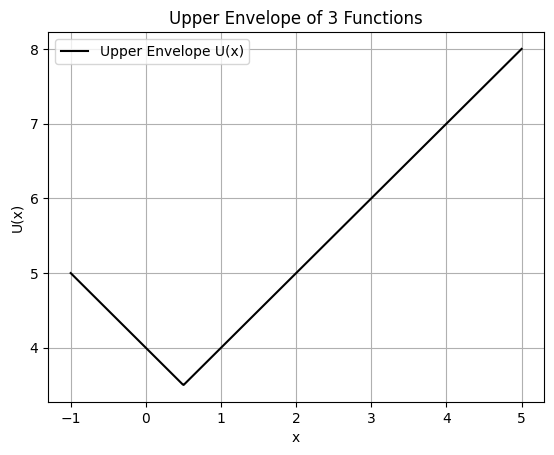

In [9]:
x_vals = np.linspace(-1, 5, 500)
y_vals = [upper_envelope(x) for x in x_vals]

plt.plot(x_vals, y_vals, label='Upper Envelope U(x)', color='black')
plt.legend()
plt.grid(True)
plt.title("Upper Envelope of 3 Functions")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.show()

In [10]:
def intersect(f1, f2):
    a1 = f1(1) - f1(0)
    b1 = f1(0)
    a2 = f2(1) - f2(0)
    b2 = f2(0)
    if a1 == a2:
        return None
    return (b2 - b1) / (a1 - a2)

xs = []
for f1, f2 in combinations(lines, 2):
    x = intersect(f1, f2)
    if x is not None:
        xs.append(x)

# You may want to restrict the domain or extend range
candidates = xs + [-100, 100]

min_val = float('inf')
min_x = None
for x in candidates:
    val = upper_envelope(x)
    if val < min_val:
        min_val = val
        min_x = x

print(f"Minimum of upper envelope is {min_val} at x = {min_x}")

Minimum of upper envelope is 3.5 at x = 0.5


## Package testing

In [11]:
from packages.Point import LocalMinima

In [ ]:
eg = LocalMinima()

eg.add_line(lambda x: x)
eg.add_line(lambda x: -x+4)
eg.add_line(lambda x: x+3)

min_val, min_x = eg.showVal(-100, 100)
print(min_x)
print(min_val)

TypeError: LocalMinima.__init__() missing 1 required positional argument: 'vertex_j'